Training set shape: (260601, 40)
Total null values in Training set: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null

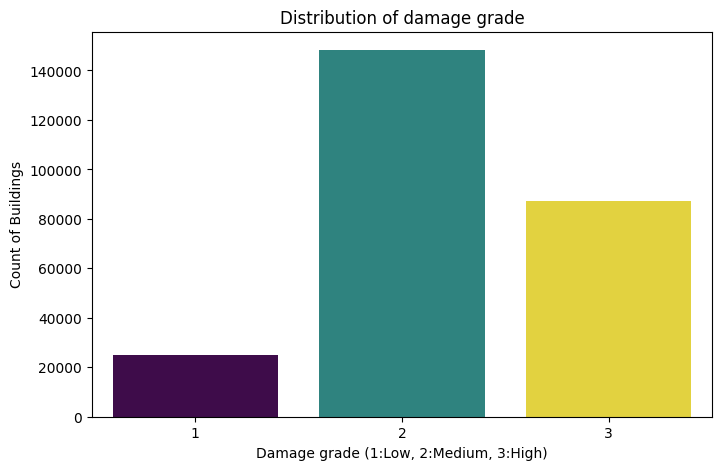


Percentage distribution of damage grade:
damage_grade
1     9.640792
2    56.891186
3    33.468022
Name: proportion, dtype: float64

------------------------------



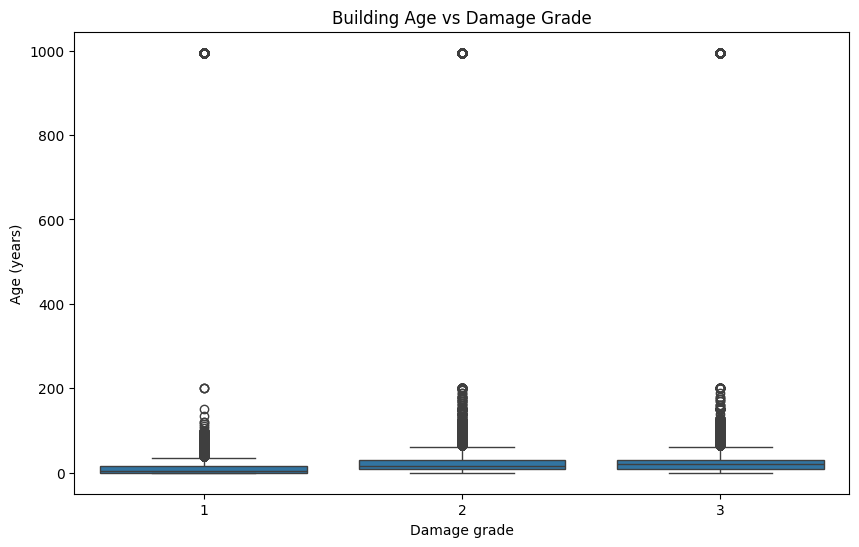


------------------------------



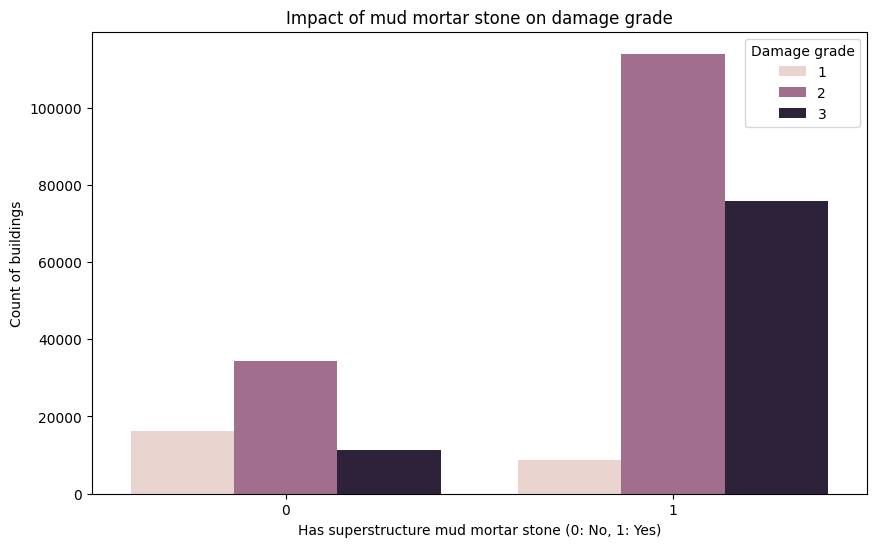

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading
train_values = pd.read_csv('/content/train_values.csv')
train_labels = pd.read_csv('/content/train_labels.csv')
test_values = pd.read_csv('/content/test_values.csv')

# Merge values and labels for data analysis
df = train_values.merge(train_labels, on='building_id')


# 2. Shape and Info Analysis
print(f"Training set shape: {df.shape}")
print(f"Total null values in Training set: {df.isnull().sum().sum()}")
df.info()

print("\n" + "-"*30 + "\n")

print(f"Test set shape: {test_values.shape}")
print(f"Total null values in Test set: {test_values.isnull().sum().sum()}")
test_values.info()

print("\n" + "-"*30 + "\n")


# 3. Numerical and Categorical Features
# Excluding 'building_id' (identifier) and 'damage_grade' (target)
features = df.drop(columns=['building_id', 'damage_grade'])

categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Note: geo_level_ids are technically integers but conceptually categorical
print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {numeric_cols}")

print("\n" + "-"*30 + "\n")


# 4. Target Feature Distribution (damage_grade)
plt.figure(figsize=(8, 5))
sns.countplot(x='damage_grade', data=df, hue='damage_grade', palette='viridis', legend=False)
plt.title('Distribution of damage grade')
plt.xlabel('Damage grade (1:Low, 2:Medium, 3:High)')
plt.ylabel('Count of Buildings')
plt.show()

# Print percentage distribution
print("\nPercentage distribution of damage grade:")
print(df['damage_grade'].value_counts(normalize=True).sort_index() * 100)

print("\n" + "-"*30 + "\n")


# 5. Visualizing Key Features
# Building age vs damage grade
plt.figure(figsize=(10, 6))
sns.boxplot(x='damage_grade', y='age', data=df)
plt.title("Building Age vs Damage Grade")
plt.xlabel('Damage grade')
plt.ylabel('Age (years)')
#plt.ylim(0, 1000)
plt.show()

print("\n" + "-"*30 + "\n")

# Superstructure analysis: Mud Mortar - Stone (common construction material)
plt.figure(figsize=(10, 6))
sns.countplot(x='has_superstructure_mud_mortar_stone', hue='damage_grade', data=df)
plt.title('Impact of mud mortar stone on damage grade')
plt.xlabel('Has superstructure mud mortar stone (0: No, 1: Yes)')
plt.ylabel('Count of buildings')
plt.legend(title='Damage grade')
plt.show()